In [1]:
REPO = '..'
RESULT_TABLE = f'{REPO}/data/table'
RESULT_OBJ = f'{REPO}/data/object'
FIGURE_FOLDER= f'{REPO}/data/figure'
SETTING_FOLDER = f'{REPO}/data/setting'
EXTERNAL_DATA=f'{REPO}/data/external'

import os
import sys
import glob
import scanpy as sc
import anndata
sys.path.append(REPO)
from settings import COLOR_PAlETTE
from utils.visual import *
import warnings
import commentjson
import pickle

### Additional Colormap
with open(f'{SETTING_FOLDER}/ColorMap.json','r') as f:
    colormap = commentjson.load(f)
COLOR_PAlETTE.update(colormap)
plt.style.use(f'{REPO}/paper.mplstyle')

warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

In [2]:
Celltype = 'Macs'

In [3]:
_stderr = sys.stderr
null = open(os.devnull,'wb')
import dill
scplus_obj = dill.load(open(f'{RESULT_OBJ}/scenic/{Celltype}/scplus_obj.pkl', 'rb'))

## Simplifying and filtering SCENIC+ output

In [4]:
scplus_obj.uns.keys()

dict_keys(['Cistromes', 'search_space', 'region_to_gene', 'TF2G_adj', 'eRegulons', 'eRegulon_metadata', 'eRegulon_signatures', 'eRegulon_AUC', 'Pseudobulk', 'TF_cistrome_correlation', 'eRegulon_AUC_thresholds', 'RSS'])

In [5]:
from scenicplus.preprocessing.filtering import apply_std_filtering_to_eRegulons
apply_std_filtering_to_eRegulons(scplus_obj)

Only keeping positive R2G
Only keep extended if not direct
Getting signatures...
Simplifying eRegulons ...


## eRegulon enrichment scores

In [6]:
from scenicplus.eregulon_enrichment import score_eRegulons
region_ranking = dill.load(open(f'{RESULT_OBJ}/scenic/{Celltype}/region_ranking.pkl', 'rb')) #load ranking calculated using the wrapper function
gene_ranking = dill.load(open(f'{RESULT_OBJ}/scenic/{Celltype}/gene_ranking.pkl', 'rb')) #load ranking calculated using the wrapper function
score_eRegulons(scplus_obj,
                ranking = region_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type= 'region',
                auc_threshold = 0.05,
                normalize = False,
                n_cpu = 5)
score_eRegulons(scplus_obj,
                gene_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type = 'gene',
                auc_threshold = 0.05,
                normalize= False,
                n_cpu = 5)

## eRegulon dimensionality reduction

In [7]:
from scenicplus.dimensionality_reduction import run_eRegulons_tsne, run_eRegulons_umap
run_eRegulons_umap(
    scplus_obj = scplus_obj,
    auc_key = 'eRegulon_AUC_filtered',
    reduction_name = 'eRegulons_UMAP', #overwrite previously calculated UMAP
)
run_eRegulons_tsne(
    scplus_obj = scplus_obj,
    auc_key = 'eRegulon_AUC_filtered',
    reduction_name = 'eRegulons_tSNE', #overwrite previously calculated tSNE
)

In [8]:
scplus_obj.metadata_cell['Cellstate']

CATGCGCAGCGGATAA-1___CCG1112_10_T2_A           Macs.Lipid
TTGCATTTCGTTTCCA-1___CCG1112_16_T1_A1          Macs.Lipid
GAGTAATAGGCCTTAG-1___CCG1112_10_T2_A     Macs.Endocytosis
GCCTCAAAGGGACCTC-1___CCG1112_10_T2_A     Macs.Endocytosis
TTACGTTTCAGGATGA-1___CCG1112_07_T2_A           Macs.Lipid
                                               ...       
AATGTCCAGCACCACA-1___CCG1112_16_T1_A1          Macs.Lipid
CATGGATTCGACAAAG-1___CCG1112_07_T2_A           Macs.Lipid
TAAGCTATCTTAGGAC-1___CCG1112_16_T1_A1          Macs.Lipid
AATTGCTCAGTTTGGC-1___CCG1112_16_T1_A1          Macs.Lipid
GCCACTAAGCCTGGTA-1___CCG1112_16_T1_A1          Macs.Lipid
Name: Cellstate, Length: 1228, dtype: object

In [9]:

adata = anndata.AnnData(obs=scplus_obj.metadata_cell[['Cellstate']],
                        obsm={'X_tsne':scplus_obj.dr_cell['eRegulons_tSNE'].values}
                       )
adata.obs['Cellstate'] = pd.Categorical(adata.obs['Cellstate'])

## correlation between TF expression and target region enrichment scores (AUC values)

In [10]:
from scenicplus.cistromes import TF_cistrome_correlation, generate_pseudobulks

generate_pseudobulks(
        scplus_obj = scplus_obj,
        variable = 'Cellstate',
        auc_key = 'eRegulon_AUC_filtered',
        signature_key = 'Gene_based')
generate_pseudobulks(
        scplus_obj = scplus_obj,
        variable = 'Cellstate',
        auc_key = 'eRegulon_AUC_filtered',
        signature_key = 'Region_based')

TF_cistrome_correlation(
            scplus_obj,
            use_pseudobulk = True,
            variable = 'Cellstate',
            auc_key = 'eRegulon_AUC_filtered',
            signature_key = 'Gene_based',
            out_key = 'filtered_gene_based')
TF_cistrome_correlation(
            scplus_obj,
            use_pseudobulk = True,
            variable = 'Cellstate',
            auc_key = 'eRegulon_AUC_filtered',
            signature_key = 'Region_based',
            out_key = 'filtered_region_based')

## select eRegulons for which the correlaiton coefficient is above 0.70 or below -0.75

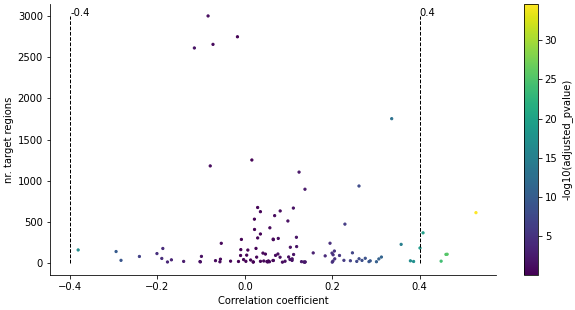

In [11]:
import numpy as np
n_targets = [int(x.split('(')[1].replace('r)', '')) for x in scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Cistrome']]
rho = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'].to_list()
adj_pval = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Adjusted_p-value'].to_list()

thresholds = {
        'rho': [-0.4, 0.4],
        'n_targets': 0
}
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5))
sc = ax.scatter(rho, n_targets, c = -np.log10(adj_pval), s = 5)
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('nr. target regions')
#ax.hlines(y = thresholds['n_targets'], xmin = min(rho), xmax = max(rho), color = 'black', ls = 'dashed', lw = 1)
ax.vlines(x = thresholds['rho'], ymin = 0, ymax = max(n_targets), color = 'black', ls = 'dashed', lw = 1)
ax.text(x = thresholds['rho'][0], y = max(n_targets), s = str(thresholds['rho'][0]))
ax.text(x = thresholds['rho'][1], y = max(n_targets), s = str(thresholds['rho'][1]))
sns.despine(ax = ax)
fig.colorbar(sc, label = '-log10(adjusted_pvalue)', ax = ax)
plt.show()

## Overlap of predicted target regions

In [12]:
selected_cistromes = scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based'].loc[
        np.logical_or(
                scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'] > thresholds['rho'][1],
                scplus_obj.uns['TF_cistrome_correlation']['filtered_region_based']['Rho'] < thresholds['rho'][0]
        )]['Cistrome'].to_list()
selected_eRegulons = [x.split('_(')[0] for x in selected_cistromes]
selected_eRegulons_gene_sig = [
        x for x in scplus_obj.uns['eRegulon_signatures_filtered']['Gene_based'].keys()
        if x.split('_(')[0] in selected_eRegulons]
selected_eRegulons_region_sig = [
        x for x in scplus_obj.uns['eRegulon_signatures_filtered']['Region_based'].keys()
        if x.split('_(')[0] in selected_eRegulons]
#save the results in the scenicplus object
scplus_obj.uns['selected_eRegulon'] = {'Gene_based': selected_eRegulons_gene_sig, 'Region_based': selected_eRegulons_region_sig}
print(f'selected: {len(selected_eRegulons_gene_sig)} eRegulons')

selected: 6 eRegulons


## Overlap of target regions of the top 5 TFs per cell type based on the Regulon Specificity Score (RSS).

In [13]:
from scenicplus.RSS import *
regulon_specificity_scores(
        scplus_obj,
        variable = 'Cellstate',
        auc_key = 'eRegulon_AUC_filtered',
        signature_keys = ['Region_based'],
        selected_regulons = [x for x in scplus_obj.uns['selected_eRegulon']['Region_based'] if '-' not in x],
        out_key_suffix = '_filtered')

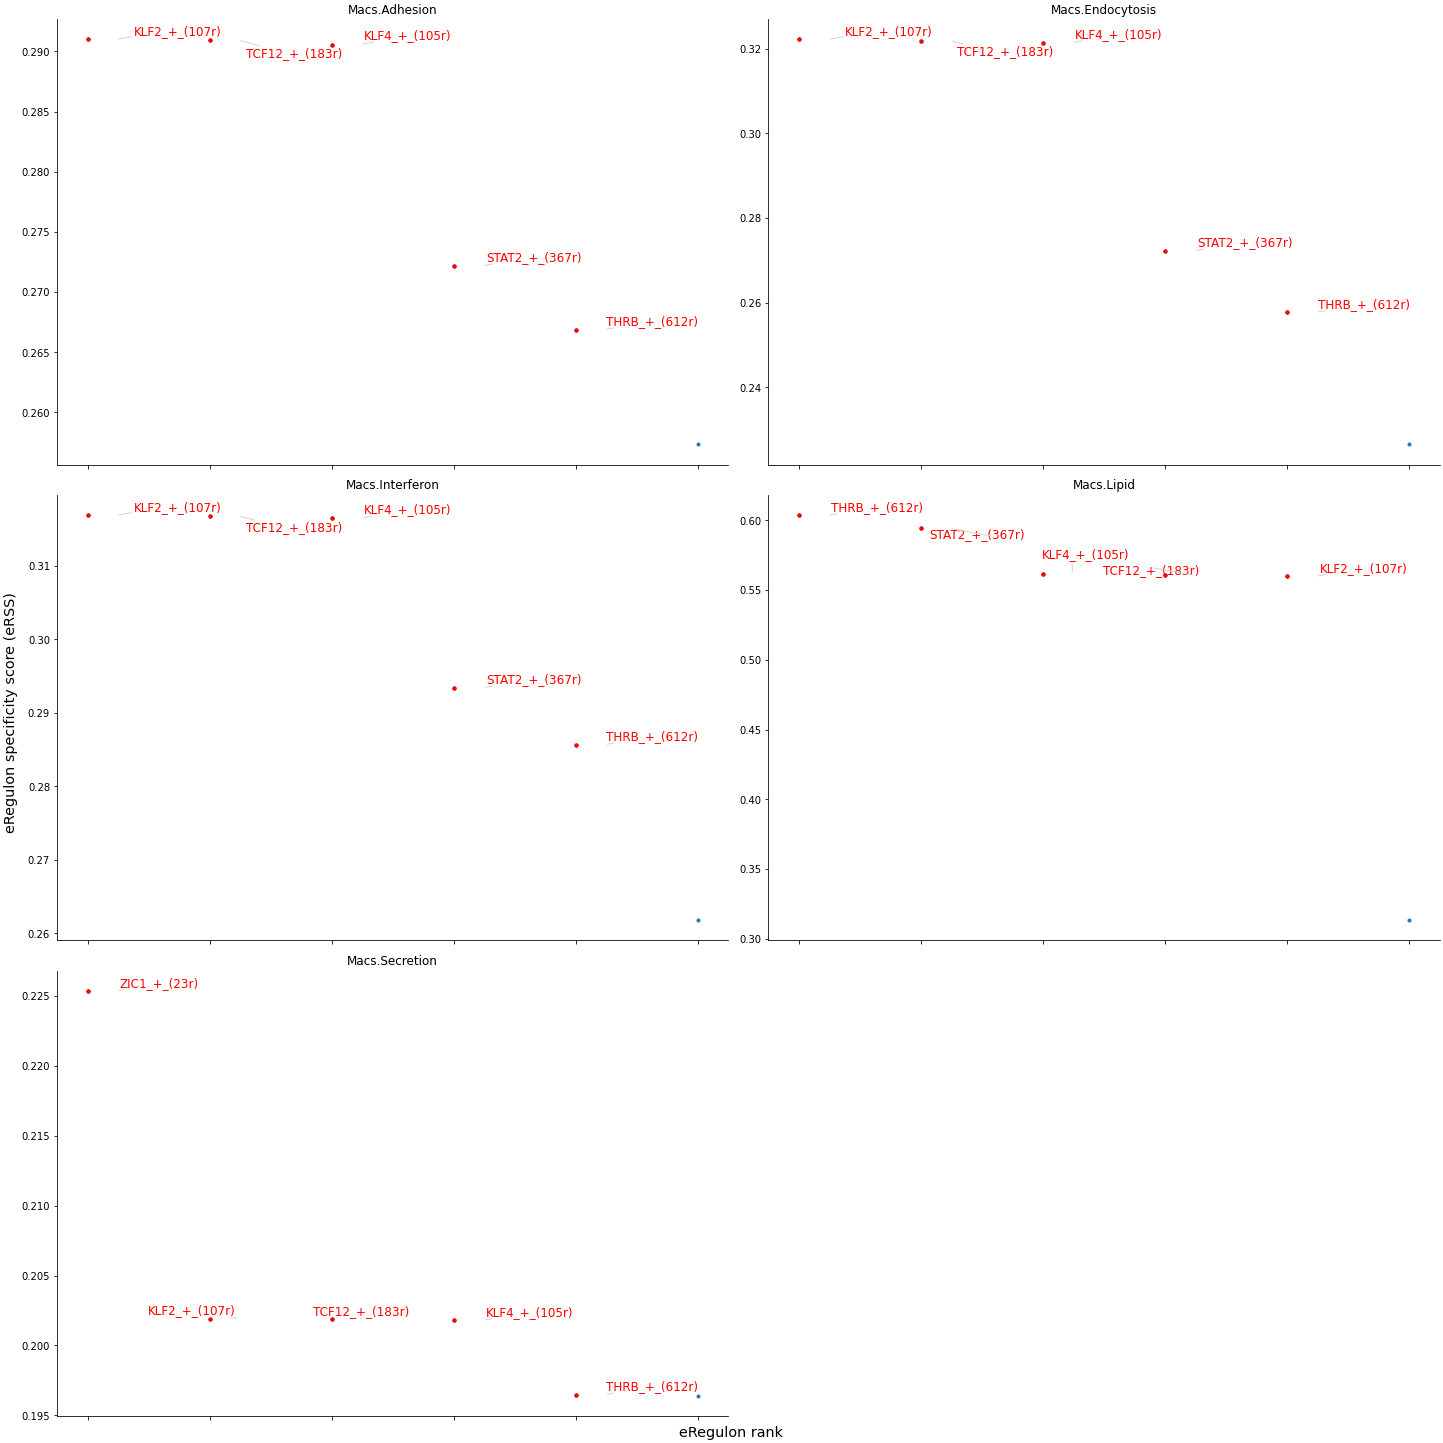

In [14]:
plot_rss(scplus_obj, 'Cellstate_filtered', num_columns=2, top_n=5, figsize = (20, 20))

In [15]:
scplus_obj.uns['selected_eRegulon']['Gene_based']

['KLF4_+_(53g)',
 'KLF2_+_(53g)',
 'THRB_+_(576g)',
 'TCF12_+_(136g)',
 'STAT2_+_(363g)',
 'ZIC1_+_(18g)']

In [16]:
from scenicplus.plotting.dotplot import generate_dotplot_df
dotplot_df=generate_dotplot_df(
     scplus_obj = scplus_obj,
        size_matrix = scplus_obj.uns['eRegulon_AUC_filtered']['Region_based'], #specify what to plot as dot sizes, target region enrichment in this case
        color_matrix = scplus_obj.to_df('EXP'), #specify  what to plot as colors, TF expression in this case
        scale_size_matrix = True,
        scale_color_matrix = True,
        group_variable = 'Cellstate',
        subset_eRegulons = scplus_obj.uns['selected_eRegulon']['Gene_based']
)

In [17]:
size_val='Target region enrichment\n(Scaled)'
color_val='TF expression\n(Scaled)'
dotplot_df.rename(columns={
    'size_val':size_val,
    'color_val':color_val
},inplace=True)

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Plotting legends..
Estimated legend width: 78.67083333333333 mm
2025-02-24 16:31:52,625 fontTools.subset INFO     maxp pruned
2025-02-24 16:31:52,640 fontTools.subset INFO     cmap pruned
2025-02-24 16:31:52,644 fontTools.subset INFO     kern dropped
2025-02-24 16:31:52,645 fontTools.subset INFO     post pruned
2025-02-24 16:31:52,647 fontTools.subset INFO     FFTM dropped
2025-02-24 16:31:52,652 fontTools.subset INFO     GPOS pruned
2025-02-24 16:31:52,657 fontTools.subset INFO     GSUB pruned
2025-02-24 16:31:52,668 fontTools.subset INFO     glyf pruned
2025-02-24 16:31:52,670 fontTools.subset INFO     Added gid0 to subset
2025-02-24 16:31:52,671 fontTools.subset INFO     Added first four glyphs to subset
2025-02-24 16:31:52,671 fontTools.subset INFO     Closing glyph list over 'GSUB': 50 glyphs before
2025-02-24 16:31:52,672 fontTools.subset I

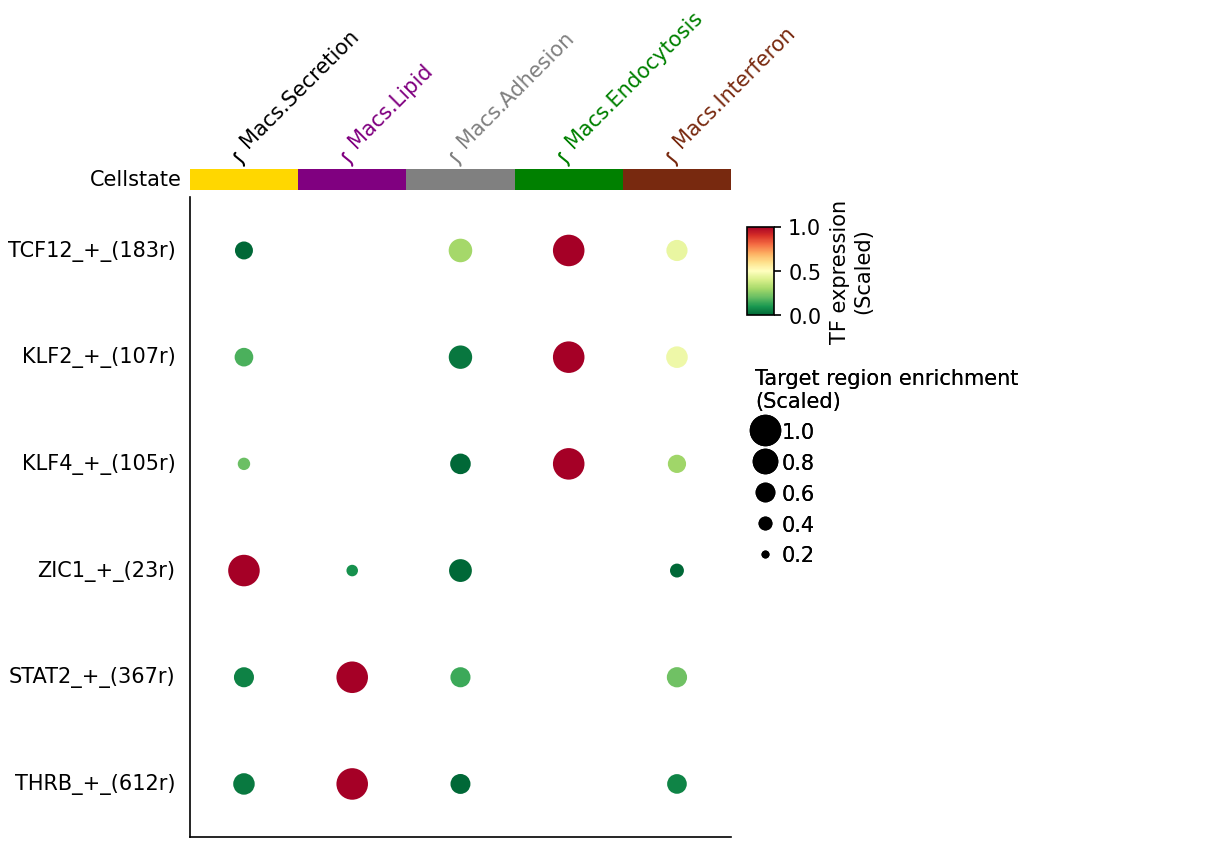

In [18]:

from PyComplexHeatmap import DotClustermapPlotter
plt.figure(figsize=(4, 5),dpi=150)
df_col = dotplot_df[['index']].drop_duplicates().set_index('index')
df_col['Cellstate'] = df_col.index
col_ha = HeatmapAnnotation(
                           label=anno_label(df_col['Cellstate'],
                                                 colors={k:v for k,v in COLOR_PAlETTE['Cellstate'].items() if k in df_col['Cellstate']},
                                                 merge=True,rotation=45),
                           Cellstate=anno_simple(df_col['Cellstate'],
                                                 colors={k:v for k,v in COLOR_PAlETTE['Cellstate'].items() if k in df_col['Cellstate']},
                                                 legend=False),
                           verbose=0,label_side='left')

cm = DotClustermapPlotter(data=dotplot_df, x='index',y='eRegulon_name',value=color_val,c=color_val,s=size_val,
                          row_cluster=True,col_cluster=True,spines=True,
                          cmap='RdYlGn_r',ratio=200,dot_legend_kws={'frameon':False},
                         top_annotation=col_ha,show_rownames=True,row_names_side='left')
plt.savefig(f'{FIGURE_FOLDER}/{Celltype}_GRN_Dotplot.pdf')

## Coverage plot

In [19]:
MP_gmt_path = f'{RESULT_TABLE}/MPs/{Celltype}/MP_Programs.gmt'
anno = pd.read_csv(f'{RESULT_TABLE}/MPs/{Celltype}/MetaProgram_Annotation.csv',index_col=0)
ref_ITH=pd.read_table(MP_gmt_path,header=None,index_col=0).drop([1],axis=1).T
MP_anno_map = anno[['MetaProgram','MPs']].drop_duplicates().set_index('MetaProgram')['MPs'].to_dict()
ref_ITH.columns = ref_ITH.columns.map(MP_anno_map)


In [20]:
import pyranges as pr
from utils.atac_plot import coveragePlot,regionPlot,genebodyPlot,read_and_filter_gtf

In [21]:
filtered_gtf = read_and_filter_gtf(f"{EXTERNAL_DATA}/gencode.v32.annotation.gtf.gz")

In [22]:
# normalize scores
mtx = np.log1p((scplus_obj.X_EXP.T /
               scplus_obj.X_EXP.sum(1) * (10 ** 4)).T)

In [23]:
scplus_obj.metadata_cell['Cellstate_format'] = scplus_obj.metadata_cell['Cellstate'].str.replace('[.+()-/\ ]','_')
scplus_obj.metadata_cell['Cellstate_show'] = scplus_obj.metadata_cell['Cellstate_format'].map(lambda x:x.replace(f'{Celltype}_','').replace('_',' '))
cellstate_maps = scplus_obj.metadata_cell[['Cellstate','Cellstate_format']].drop_duplicates().set_index('Cellstate')['Cellstate_format'].to_dict()
bw_dict  = {
    os.path.basename(x).replace('.bw','').replace(f'{Celltype}_','').replace('_',' '):x 
    for x in glob.glob(f'{RESULT_OBJ}/consensus_per_celltype/{Celltype}/consensus_peak_calling/pseudobulk_bw_files/*.bw') if os.path.basename(x).replace('.bw','') in scplus_obj.metadata_cell['Cellstate_format'].unique()
}
color_dict = { cellstate_maps[k].replace(f'{Celltype}_','').replace('_',' '):v for k,v in COLOR_PAlETTE['Cellstate'].items() if k in cellstate_maps}

In [24]:
tf_df = scplus_obj.uns['eRegulon_metadata_filtered']
show_tf = tf_df.loc[(tf_df.Region_signature_name=='TCF12_+_(183r)')&(tf_df.Gene.isin(ref_ITH['Endocytosis'].tolist())),:]
show_tf.sort_values('R2G_importance',ascending=False)

,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
160,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr8:86342294-86342794,WWP1,0.152598,0.170649,0.026041,0.026041,19.832211,1,0.454552,9.014776,9.014776,TCF12_+_+
132,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr2:200525848-200526348,SPATS2L,0.096220,0.138099,0.013288,0.013288,18.823924,1,0.341155,6.421870,6.421870,TCF12_+_+
55,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr10:50624303-50624803,SGMS1,0.075125,0.095369,0.007165,0.007165,35.896575,1,0.561947,20.171956,20.171956,TCF12_+_+
82,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr21:33642219-33642719,ITSN1,0.063535,0.150475,0.009560,0.009560,23.257378,1,0.583664,13.574494,13.574494,TCF12_+_+
170,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr5:39424789-39425289,DAB2,0.059975,0.278653,0.016712,0.016712,27.183382,1,0.350457,9.526612,9.526612,TCF12_+_+
18,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr16:79600591-79601091,MAF,0.056768,0.106342,0.006037,0.006037,5.413383,1,0.328529,1.778455,1.778455,TCF12_+_+
179,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr1:183635646-183636146,RGL1,0.051080,0.135212,0.006907,0.006907,5.263048,1,0.300692,1.582555,1.582555,TCF12_+_+
134,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr1:61077795-61078295,NFIA,0.045120,0.149207,0.006732,0.006732,12.971447,1,0.356227,4.620785,4.620785,TCF12_+_+
83,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr21:33641708-33642208,ITSN1,0.040040,0.141925,0.005683,0.005683,23.257378,1,0.583664,13.574494,13.574494,TCF12_+_+
143,TCF12_+_(183r),TCF12_+_(136g),TCF12,False,chr14:92793916-92794416,LGMN,0.038477,0.155746,0.005993,0.005993,10.435518,1,0.346940,3.620495,3.620495,TCF12_+_+


In [25]:
show_tf = tf_df.loc[(tf_df.Region_signature_name=='KLF4_+_(105r)')&(tf_df.Gene.isin(ref_ITH['Endocytosis'].tolist())),:]
show_tf.sort_values('R2G_importance',ascending=False)

,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
105,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr8:86342294-86342794,WWP1,0.152598,0.170649,0.026041,0.026041,3.277132,1,0.201745,0.661146,0.661146,KLF4_+_+
29,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr1:207751775-207752275,CR1,0.146072,0.178119,0.026018,0.026018,4.368217,1,0.211398,0.923432,0.923432,KLF4_+_+
63,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr6:83193041-83193541,ME1,0.078271,0.186243,0.014577,0.014577,6.513070,1,0.209537,1.364730,1.364730,KLF4_+_+
90,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr3:143971740-143972240,SLC9A9,0.063663,0.337704,0.021499,0.021499,10.890589,1,0.299905,3.266138,3.266138,KLF4_+_+
45,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr6:119449327-119449827,MAN1A1,0.063055,0.114224,0.007202,0.007202,2.687182,1,0.176366,0.473926,0.473926,KLF4_+_+
43,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr6:119147226-119147726,MAN1A1,0.058776,0.058500,0.003438,0.003438,2.687182,1,0.176366,0.473926,0.473926,KLF4_+_+
98,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr1:61077795-61078295,NFIA,0.045120,0.149207,0.006732,0.006732,1.775270,1,0.191641,0.340215,0.340215,KLF4_+_+
44,KLF4_+_(105r),KLF4_+_(53g),KLF4,False,chr6:119334893-119335393,MAN1A1,0.028925,0.087658,0.002536,0.002536,2.687182,1,0.176366,0.473926,0.473926,KLF4_+_+


### Endocytosis genes related regulons

In [30]:
bw_dict.keys()

dict_keys(['Secretion', 'Endocytosis', 'Lipid', 'Adhesion', 'Interferon'])

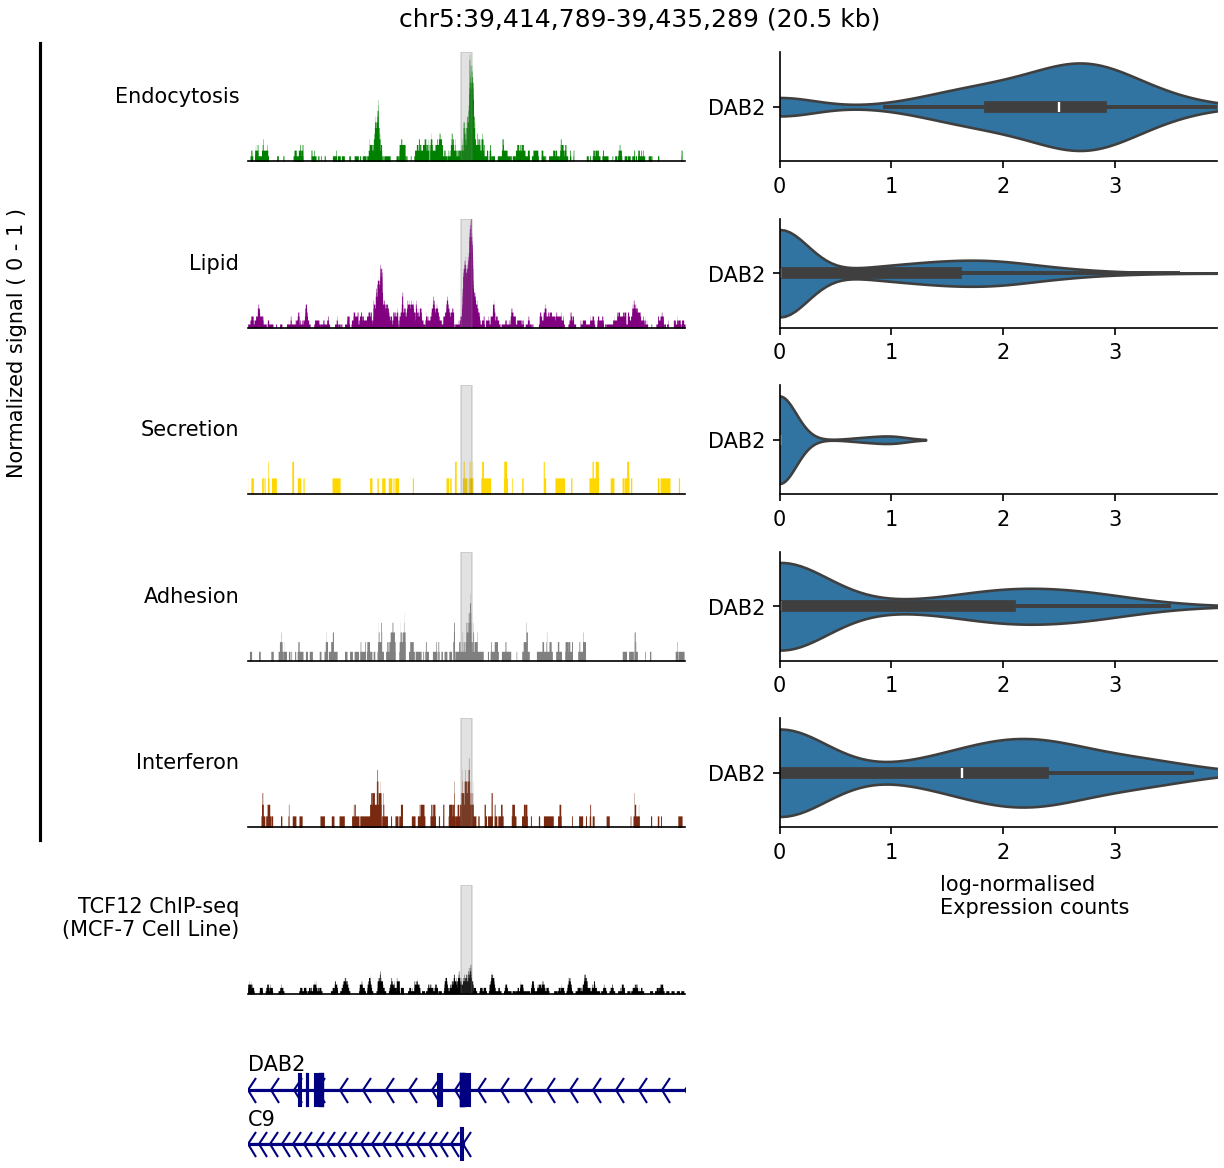

In [35]:
ylim_max=1
offset = 10000
tf_gene = 'TCF12'
gene = 'DAB2'
# get expression values for gene/genes
idx_gene = [list(scplus_obj.gene_names).index(g) for g in [gene]]
rna_data = pd.DataFrame(mtx[:, idx_gene],columns=[gene])
rna_data['celltype']= scplus_obj.metadata_cell['Cellstate_show'].tolist()
# regions
regions = tf_df.loc[tf_df.Gene==gene,'Region'].str.split(':',expand=True)
regions.columns = ['chr','pos']
regions[['start','end']] = regions['pos'].str.split('-',expand=True).astype(int)
chrom,start,end=regions['chr'].unique()[0],regions['start'].min()-offset,regions['end'].max()+offset
hregions= []
for _,row in regions.iterrows():
    hregions.append((row['start'],row['end']))

fig,axs = plt.subplot_mosaic([[f'{ct}_peak',f'{ct}_rna']
                              for ct in ['Endocytosis', 'Lipid','Secretion', 'Adhesion', 'Interferon'] ] + [['A','A1'],['B','B1']],
                            figsize=(8,8),dpi=150)

for ct,bw_file in bw_dict.items():
    coveragePlot(bw_file,chrom,start,end,highlight_regions=hregions,ax=axs[f"{ct}_peak"],color=color_dict[ct],label=ct,ylim_max=ylim_max)
    sns.violinplot(data=rna_data.loc[rna_data.celltype==ct,:].drop(['celltype'],axis=1).melt(),x='value',y='variable',
                   ax=axs[f"{ct}_rna"])
    axs[f"{ct}_rna"].set(xlabel='',ylabel='')
    axs[f"{ct}_rna"].set_xlim(rna_data[gene].min(),rna_data[gene].max())

    
line = plt.Line2D((0, 0), (2/(len(bw_dict)+2), .95),transform=fig.transFigure, color="k")
fig.add_artist(line)
fig.text(-0.01, (len(bw_dict)-1.5)/len(bw_dict) , f"Normalized signal ( 0 - {ylim_max} )", va="center", ha='right',rotation=90)
fig.text(.75, 1.8/(len(bw_dict)+2) , "log-normalised\nExpression counts", va="top", ha='left')

# regionPlot(pr_consensus_bed,chrom,start,end,ax=axs['A'],label='Consensus Peaks')
# chipseq = pr.read_bed(f'{EXTERNAL_DATA}/CistromePeaks/GSM1010861_TCF12.bed')
# regionPlot(chipseq,chrom,start,end,ax=axs['A'],label='TCF12 ChIP-seq Peaks',highlight_regions=hregions)
coveragePlot(f'{EXTERNAL_DATA}/CistromePeaks/46321_treat.bw',chrom,start,end,highlight_regions=hregions,ax=axs['A'],color='k',label='TCF12 ChIP-seq\n(MCF-7 Cell Line)',ylim_max=ylim_max)
genebodyPlot(filtered_gtf,chrom,start,end,ax=axs['B'],gene_fontsize=10,gene_gap_ratio=.7)

for name in ['A1','B1']:
    axs[name].remove()

fig.suptitle(f'{chrom}:{start:,}-{end:,} ({(end - start)/1000:.1f} kb)');
plt.savefig(f'{FIGURE_FOLDER}/Suppl_XX_{Celltype}_GRN_Endocytosis.svg',dpi=200,bbox_inches='tight')

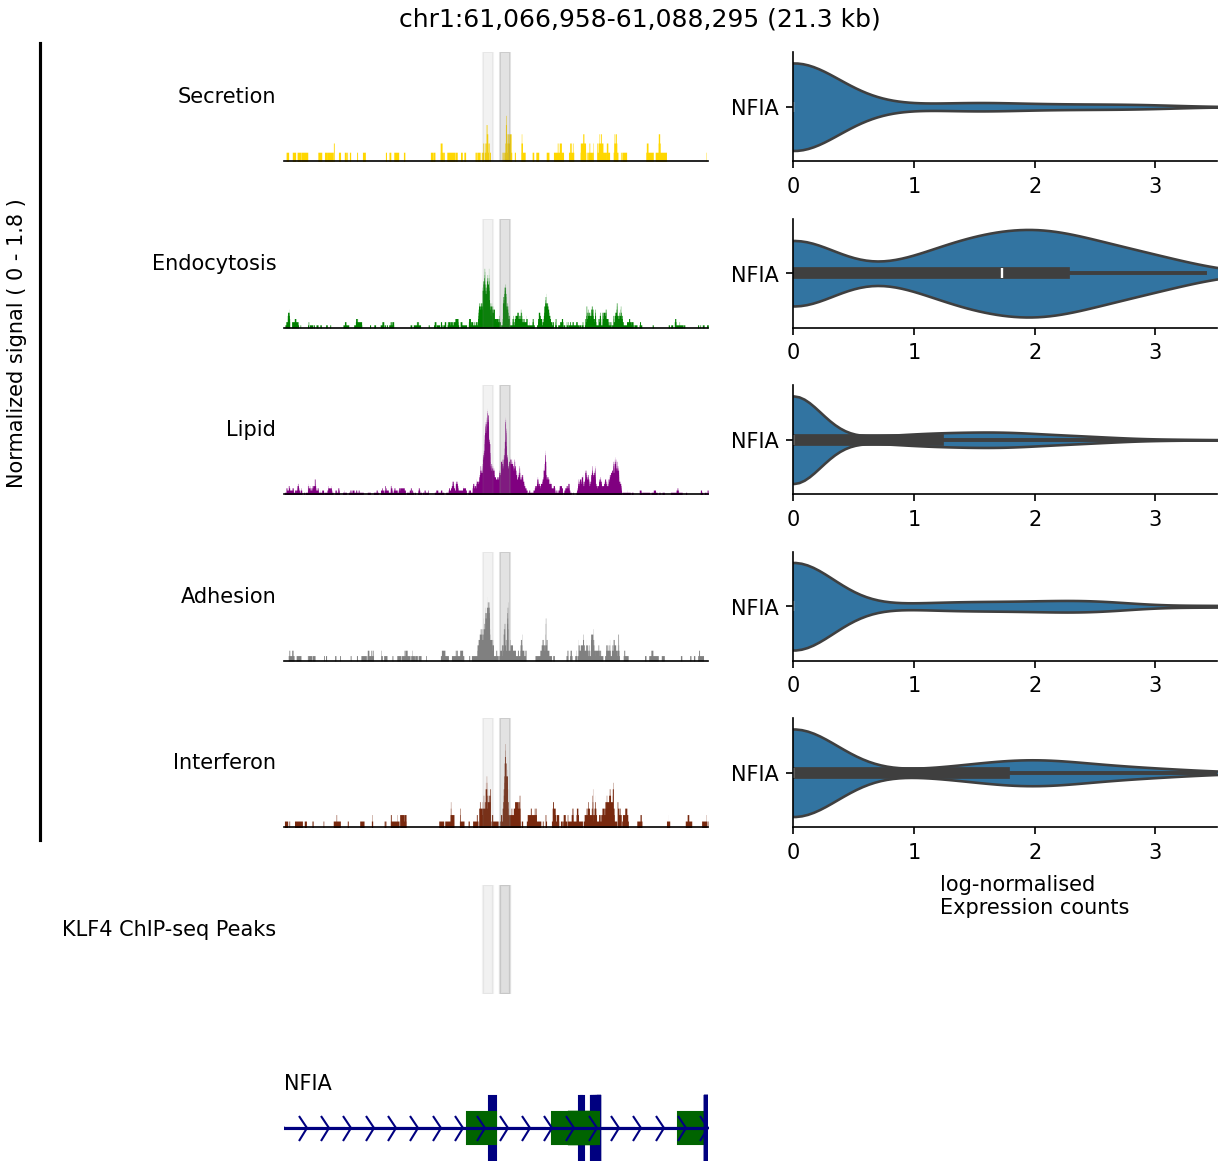

In [34]:
ylim_max=1.8
offset = 10000
tf_gene = 'KLF4'
gene = 'NFIA'
# get expression values for gene/genes
idx_gene = [list(scplus_obj.gene_names).index(g) for g in [gene]]
rna_data = pd.DataFrame(mtx[:, idx_gene],columns=[gene])
rna_data['celltype']= scplus_obj.metadata_cell['Cellstate_show'].tolist()
# regions
regions = tf_df.loc[tf_df.Gene==gene,'Region'].str.split(':',expand=True)
regions.columns = ['chr','pos']
regions[['start','end']] = regions['pos'].str.split('-',expand=True).astype(int)
chrom,start,end=regions['chr'].unique()[0],regions['start'].min()-offset,regions['end'].max()+offset
hregions= []
for _,row in regions.iterrows():
    hregions.append((row['start'],row['end']))

fig,axs = plt.subplot_mosaic([[f'{ct}_peak',f'{ct}_rna']
                              for ct in bw_dict.keys() ] + [['A','A1'],['B','B1']],
                            figsize=(8,8),dpi=150)

for ct,bw_file in bw_dict.items():
    coveragePlot(bw_file,chrom,start,end,highlight_regions=hregions,ax=axs[f"{ct}_peak"],color=color_dict[ct],label=ct,ylim_max=ylim_max)
    sns.violinplot(data=rna_data.loc[rna_data.celltype==ct,:].drop(['celltype'],axis=1).melt(),x='value',y='variable',
                   ax=axs[f"{ct}_rna"])
    axs[f"{ct}_rna"].set(xlabel='',ylabel='')
    axs[f"{ct}_rna"].set_xlim(rna_data[gene].min(),rna_data[gene].max())

    
line = plt.Line2D((0, 0), (2/(len(bw_dict)+2), .95),transform=fig.transFigure, color="k")
fig.add_artist(line)
fig.text(-0.01, (len(bw_dict)-1.5)/len(bw_dict) , f"Normalized signal ( 0 - {ylim_max} )", va="center", ha='right',rotation=90)
fig.text(.75, 1.8/(len(bw_dict)+2) , "log-normalised\nExpression counts", va="top", ha='left')

# regionPlot(pr_consensus_bed,chrom,start,end,ax=axs['A'],label='Consensus Peaks')
chipseq = pr.read_bed(f'{EXTERNAL_DATA}/CistromePeaks/GSM1019134_KLF4.bed')
regionPlot(chipseq,chrom,start,end,ax=axs['A'],label='KLF4 ChIP-seq Peaks',highlight_regions=hregions)
genebodyPlot(filtered_gtf,chrom,start,end,ax=axs['B'],gene_fontsize=10,gene_gap_ratio=.7)

for name in ['A1','B1']:
    axs[name].remove()

fig.suptitle(f'{chrom}:{start:,}-{end:,} ({(end - start)/1000:.1f} kb)');
# plt.savefig(f'{FIGURE_FOLDER}/Suppl_XX_{Celltype}_GRN_Endocytosis.svg',dpi=200,bbox_inches='tight')

### Lipid

In [263]:
tf_df = scplus_obj.uns['eRegulon_metadata_filtered']
show_tf = tf_df.loc[(tf_df.Region_signature_name=='STAT2_+_(367r)')&(tf_df.Gene.isin(ref_ITH['Lipid'].tolist())),:]
show_tf.sort_values('R2G_importance',ascending=False)

,Region_signature_name,Gene_signature_name,TF,is_extended,Region,Gene,R2G_importance,R2G_rho,R2G_importance_x_rho,R2G_importance_x_abs_rho,TF2G_importance,TF2G_regulation,TF2G_rho,TF2G_importance_x_abs_rho,TF2G_importance_x_rho,Consensus_name
199,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr8:38901447-38901947,HTRA4,0.045691,0.096072,0.004390,0.004390,3.380299,1,0.244774,0.827408,0.827408,STAT2_+_+
420,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr3:12187631-12188131,PPARG,0.028744,0.116124,0.003338,0.003338,0.852315,1,0.148519,0.126585,0.126585,STAT2_+_+
229,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr12:68787438-68787938,CPM,0.026702,0.258505,0.006903,0.006903,0.874190,1,0.364857,0.318955,0.318955,STAT2_+_+
180,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr14:54776274-54776774,SAMD4A,0.018733,0.190771,0.003574,0.003574,0.458774,1,0.223884,0.102712,0.102712,STAT2_+_+
179,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr14:54567679-54568179,SAMD4A,0.017671,0.205296,0.003628,0.003628,0.458774,1,0.223884,0.102712,0.102712,STAT2_+_+
363,STAT2_+_(367r),STAT2_+_(363g),STAT2,False,chr16:31243930-31244430,ITGAX,0.013397,0.267980,0.003590,0.003590,0.720664,1,0.243399,0.175409,0.175409,STAT2_+_+


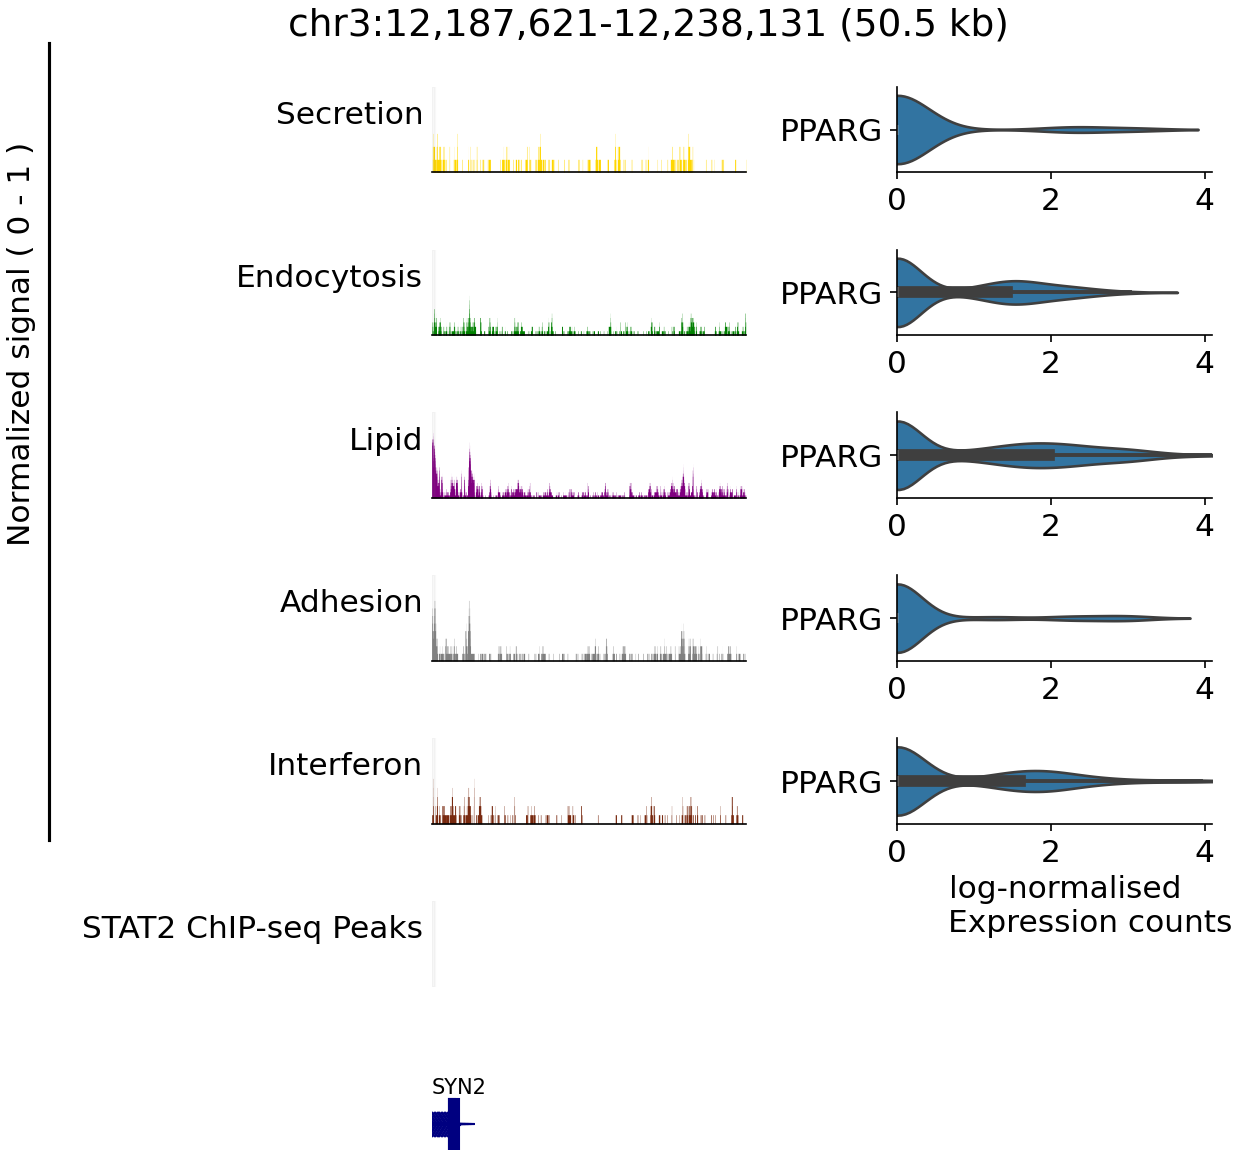

In [286]:
ylim_max=1
offset = 50000
tf_gene = 'STAT2'
gene = 'PPARG'
# get expression values for gene/genes
idx_gene = [list(scplus_obj.gene_names).index(g) for g in [gene]]
rna_data = pd.DataFrame(mtx[:, idx_gene],columns=[gene])
rna_data['celltype']= scplus_obj.metadata_cell['Cellstate_show'].tolist()
# regions
regions = tf_df.loc[(tf_df.Gene==gene)&(tf_df.TF=='STAT2'),'Region'].str.split(':',expand=True)
regions.columns = ['chr','pos']
regions[['start','end']] = regions['pos'].str.split('-',expand=True).astype(int)
chrom,start,end=regions['chr'].unique()[0],regions['start'].min()-10,regions['end'].max()+offset
hregions= []
for _,row in regions.iterrows():
    hregions.append((row['start'],row['end']))

fig,axs = plt.subplot_mosaic([[f'{ct}_peak',f'{ct}_rna']
                              for ct in bw_dict.keys() ] + [['A','A1'],['B','B1']],
                            figsize=(8,8),dpi=150)

for ct,bw_file in bw_dict.items():
    coveragePlot(bw_file,chrom,start,end,highlight_regions=hregions,ax=axs[f"{ct}_peak"],color=color_dict[ct],label=ct,ylim_max=ylim_max)
    sns.violinplot(data=rna_data.loc[rna_data.celltype==ct,:].drop(['celltype'],axis=1).melt(),x='value',y='variable',
                   ax=axs[f"{ct}_rna"])
    axs[f"{ct}_rna"].set(xlabel='',ylabel='')
    axs[f"{ct}_rna"].set_xlim(rna_data[gene].min(),rna_data[gene].max())

    
line = plt.Line2D((0, 0), (2/(len(bw_dict)+2), .95),transform=fig.transFigure, color="k")
fig.add_artist(line)
fig.text(-0.01, (len(bw_dict)-1.5)/len(bw_dict) , f"Normalized signal ( 0 - {ylim_max} )", va="center", ha='right',rotation=90)
fig.text(.75, 1.8/(len(bw_dict)+2) , "log-normalised\nExpression counts", va="top", ha='left')

# regionPlot(pr_consensus_bed,chrom,start,end,ax=axs['A'],label='Consensus Peaks')
chipseq = pr.read_bed(f'{EXTERNAL_DATA}/CistromePeaks/GSM2574755_STAT2.bed')
regionPlot(chipseq,chrom,start,end,ax=axs['A'],label='STAT2 ChIP-seq Peaks',highlight_regions=hregions)
genebodyPlot(filtered_gtf,chrom,start,end,ax=axs['B'],gene_fontsize=10,gene_gap_ratio=.7)

for name in ['A1','B1']:
    axs[name].remove()

fig.suptitle(f'{chrom}:{start:,}-{end:,} ({(end - start)/1000:.1f} kb)');